# Quiz: Stochastic Processes Simulations

This notebook simulates and compares four discrete-time stochastic systems:
1. AWGN filtered by a low-pass system $H(\omega)$
2. AR(3) process
3. ARMA(3, 6) process
4. Random Walk process

Each process is represented with the same `StochasticProcess` dataclass and visualized in three domains: realization in $t$, autocorrelation in $\tau$, and PSD in $\omega$.

In [29]:
from __future__ import annotations

from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch


@dataclass(frozen=True)
class StochasticProcess:
    """Stores one realization and its lag/frequency-domain summaries."""

    realization: np.ndarray  # Process samples x[t] [a.u.]
    acf: tuple[np.ndarray, np.ndarray]  # (tau_samples, R_x[tau])
    psd: tuple[np.ndarray, np.ndarray]  # (omega_rad, S_x[omega])


def welch_psd_torch(
    realization: np.ndarray,             # Input realization x[t]
    n_fft: int = 1024,                   # Number of FFT bins
    segment_length_samples: int = 256,   # Welch segment length [samples]
    overlap_samples: int = 128,          # Overlap between segments [samples]
) -> tuple[np.ndarray, np.ndarray]:      # (omega_rad, normalized_psd)
    """Estimate a two-sided Welch PSD using PyTorch FFT primitives.

    Purpose:
        Compute an averaged periodogram estimate with Hann windowing and
        overlapping segments, using PyTorch for the FFT pipeline.
    Parameters:
        realization: One-dimensional realization x[t].
        n_fft: Number of FFT bins.
        segment_length_samples: Welch window length [samples].
        overlap_samples: Overlap between adjacent windows [samples].
    Returns:
        `(omega_rad, psd_values)` where `omega_rad` is in [-pi, pi) and
        `psd_values` is normalized to unit maximum for comparison plots.
    Side effects:
        None.
    Assumptions:
        Input is real-valued and long enough for at least one Welch segment.
    """
    if realization.ndim != 1:
        raise ValueError("realization must be a 1-D array.")
    if n_fft < 16:
        raise ValueError("n_fft must be >= 16 for a meaningful PSD.")
    if segment_length_samples < 8:
        raise ValueError("segment_length_samples must be >= 8.")
    if overlap_samples < 0 or overlap_samples >= segment_length_samples:
        raise ValueError("overlap_samples must satisfy 0 <= overlap < segment_length.")

    num_samples = realization.size
    if num_samples <= segment_length_samples:
        raise ValueError("realization length must exceed segment_length_samples.")

    x_tensor = torch.as_tensor(realization, dtype=torch.float64)
    step_samples = segment_length_samples - overlap_samples

    # Build overlapping frames with index-based slicing for Welch averaging.
    segment_starts = torch.arange(
        0,
        num_samples - segment_length_samples + 1,
        step_samples,
        dtype=torch.int64,
    )
    if int(segment_starts.numel()) == 0:
        raise RuntimeError("Welch PSD failed: no valid segments were generated.")

    frame_offsets = torch.arange(segment_length_samples, dtype=torch.int64)
    frame_indices = segment_starts[:, None] + frame_offsets[None, :]
    segments = x_tensor[frame_indices]

    # Apply Hann window and average two-sided periodograms in the FFT domain.
    window = torch.hann_window(segment_length_samples, periodic=False, dtype=torch.float64)
    window_power = torch.sum(window**2).clamp_min(torch.finfo(torch.float64).eps)
    spectra = torch.fft.fft(segments * window.unsqueeze(0), n=n_fft, dim=1)
    periodograms = torch.abs(spectra) ** 2 / window_power
    psd_two_sided = torch.mean(periodograms, dim=0)

    # Shift to [-pi, pi) and normalize amplitude for consistent visualization.
    psd_shifted = torch.fft.fftshift(psd_two_sided)
    psd_values = psd_shifted / torch.max(psd_shifted).clamp_min(torch.finfo(torch.float64).eps)
    omega_rad = torch.linspace(-torch.pi, torch.pi, n_fft + 1, dtype=torch.float64)[:-1]

    return omega_rad.cpu().numpy(), psd_values.cpu().numpy()


def estimate_acf_psd(
    realization: np.ndarray,             # Process samples x[t]
    max_lag_samples: int = 128,          # Maximum lag for ACF [samples]
    n_fft: int = 1024,                   # Frequency bins for PSD estimation
    segment_length_samples: int = 256,   # Welch segment length [samples]
    overlap_samples: int = 128,          # Overlap between Welch segments [samples]
) -> tuple[tuple[np.ndarray, np.ndarray], tuple[np.ndarray, np.ndarray]]:
    """Estimate normalized ACF and Welch PSD from one realization.

    Purpose:
        Build an empirical autocorrelation around tau=0 and estimate the PSD
        with Welch's method (windowed averaged periodograms).
    Parameters:
        realization: One-dimensional realization x[t].
        max_lag_samples: Number of positive/negative lags to keep [samples].
        n_fft: Number of frequency samples for PSD discretization.
        segment_length_samples: Welch segment length [samples].
        overlap_samples: Overlap between adjacent Welch segments [samples].
    Returns:
        A pair `(acf, psd)` where:
        - `acf = (tau_samples, R_x[tau])` with normalized R_x[0] = 1.
        - `psd = (omega_rad, S_x[omega])` from Welch, normalized to max value 1.
    Side effects:
        None.
    Assumptions:
        Input is real-valued and long enough for requested lag and Welch window.
    """
    if realization.ndim != 1:
        raise ValueError("realization must be a 1-D array.")
    if max_lag_samples < 1:
        raise ValueError("max_lag_samples must be >= 1.")

    x_centered = realization - np.mean(realization)
    num_samples = x_centered.size

    # Compute full empirical autocorrelation and keep a symmetric lag window.
    acf_full = np.correlate(x_centered, x_centered, mode="full") / num_samples
    lags_full = np.arange(-num_samples + 1, num_samples)
    valid_lag_mask = np.abs(lags_full) <= min(max_lag_samples, num_samples - 1)
    tau_samples = lags_full[valid_lag_mask]
    acf_values = acf_full[valid_lag_mask]

    # Normalize ACF by zero-lag value for easier comparison across processes.
    acf_zero = float(acf_values[tau_samples == 0][0])
    acf_values = acf_values / max(acf_zero, np.finfo(float).eps)

    # Estimate Welch PSD through the dedicated PyTorch implementation.
    omega_rad, psd_values = welch_psd_torch(
        realization=x_centered,
        n_fft=n_fft,
        segment_length_samples=segment_length_samples,
        overlap_samples=overlap_samples,
    )

    return (tau_samples.astype(np.int64), acf_values), (omega_rad, psd_values)


def build_lowpass_fir(
    num_taps: int,                # Number of FIR taps
    cutoff_rad: float,            # Cutoff angular frequency [rad/sample]
) -> np.ndarray:                  # Low-pass FIR impulse response h[t]
    """Design a windowed-sinc low-pass FIR with unit gain at DC."""
    if num_taps % 2 == 0:
        raise ValueError("num_taps must be odd for linear-phase centering.")
    if not 0.0 < cutoff_rad < np.pi:
        raise ValueError("cutoff_rad must satisfy 0 < cutoff_rad < pi.")

    # Build an ideal low-pass and taper it with a Hamming window.
    n = np.arange(num_taps) - (num_taps - 1) / 2
    normalized_cutoff = cutoff_rad / np.pi
    h = normalized_cutoff * np.sinc(normalized_cutoff * n)
    h *= np.hamming(num_taps)

    # Normalize to keep DC gain equal to 1 after filtering.
    h /= np.sum(h)
    return h


def simulate_filtered_awgn(
    num_samples: int,             # Number of output samples
    rng: np.random.Generator,     # Random generator for reproducibility
    cutoff_rad: float,            # LPF cutoff [rad/sample]
    num_taps: int = 41,           # FIR length
) -> np.ndarray:                 # Filtered AWGN realization x[t]
    """Generate AWGN passed through a low-pass FIR system H(omega)."""
    h = build_lowpass_fir(num_taps=num_taps, cutoff_rad=cutoff_rad)

    # Pad input noise so convolution can return exactly num_samples points.
    white_noise = rng.standard_normal(num_samples + num_taps - 1)
    filtered_noise = np.convolve(white_noise, h, mode="valid")
    return filtered_noise[:num_samples]


def simulate_ar_process(
    num_samples: int,             # Number of output samples
    ar_coeffs: np.ndarray,        # AR coefficients [a1, ..., ap]
    rng: np.random.Generator,     # Random generator for innovation noise
    noise_std: float = 1.0,       # Innovation standard deviation
    burn_in_samples: int = 500,   # Warm-up samples to reduce transients
) -> np.ndarray:                 # AR realization x[t]
    """Simulate x[t] = sum_k a_k x[t-k] + w[t] for a stable AR model."""
    p_order = int(ar_coeffs.size)
    total_samples = num_samples + burn_in_samples + p_order
    innovations = noise_std * rng.standard_normal(total_samples)
    x = np.zeros(total_samples)

    # Recursively build AR samples from past outputs and current innovation.
    for idx in range(p_order, total_samples):
        ar_term = float(ar_coeffs @ x[idx - p_order:idx][::-1]) if p_order else 0.0
        x[idx] = ar_term + innovations[idx]

    start_idx = burn_in_samples + p_order
    return x[start_idx:start_idx + num_samples]


def simulate_arma_process(
    num_samples: int,             # Number of output samples
    ar_coeffs: np.ndarray,        # AR coefficients [a1, ..., ap]
    ma_coeffs: np.ndarray,        # MA coefficients [b1, ..., bq]
    rng: np.random.Generator,     # Random generator for innovation noise
    noise_std: float = 1.0,       # Innovation standard deviation
    burn_in_samples: int = 500,   # Warm-up samples to reduce transients
) -> np.ndarray:                 # ARMA realization x[t]
    """Simulate x[t] = sum_k a_k x[t-k] + w[t] + sum_l b_l w[t-l]."""
    p_order = int(ar_coeffs.size)
    q_order = int(ma_coeffs.size)
    max_order = max(p_order, q_order)

    total_samples = num_samples + burn_in_samples + max_order
    innovations = noise_std * rng.standard_normal(total_samples)
    x = np.zeros(total_samples)

    # Recursively combine AR memory with MA colored innovation term.
    for idx in range(max_order, total_samples):
        ar_term = float(ar_coeffs @ x[idx - p_order:idx][::-1]) if p_order else 0.0
        ma_term = float(ma_coeffs @ innovations[idx - q_order:idx][::-1]) if q_order else 0.0
        x[idx] = ar_term + innovations[idx] + ma_term

    start_idx = burn_in_samples + max_order
    return x[start_idx:start_idx + num_samples]


def simulate_random_walk(
    num_samples: int,             # Number of output samples
    rng: np.random.Generator,     # Random generator for incremental noise
    step_std: float = 1.0,        # Step standard deviation
) -> np.ndarray:                 # Random walk realization x[t]
    """Generate a random walk by cumulative summation of Gaussian steps."""
    increments = step_std * rng.standard_normal(num_samples)
    return np.cumsum(increments)


def build_stochastic_process(
    realization: np.ndarray,         # Process realization x[t]
    max_lag_samples: int,            # Maximum lag for ACF [samples]
    n_fft: int,                      # Number of frequency bins for PSD
    segment_length_samples: int,     # Welch segment length [samples]
    overlap_samples: int,            # Welch overlap [samples]
) -> StochasticProcess:              # Dataclass with realization, ACF, and PSD
    """Create a StochasticProcess object from one realization."""
    acf, psd = estimate_acf_psd(
        realization=realization,
        max_lag_samples=max_lag_samples,
        n_fft=n_fft,
        segment_length_samples=segment_length_samples,
        overlap_samples=overlap_samples,
    )
    return StochasticProcess(realization=realization, acf=acf, psd=psd)


In [30]:
rng = np.random.default_rng(seed=42)

num_samples = 2048
max_lag_samples = 160
n_fft = 2048
segment_length_samples = 256
overlap_samples = 128

# Define one realization per process family requested in the quiz statement.
realizations = {
    "Filtered AWGN (LPF)": simulate_filtered_awgn(
        num_samples=num_samples,
        rng=rng,
        cutoff_rad=0.35 * np.pi,
        num_taps=41,
    ),
    "AR(3)": simulate_ar_process(
        num_samples=num_samples,
        ar_coeffs=np.array([0.75, -0.30, 0.12]),
        rng=rng,
        noise_std=1.0,
        burn_in_samples=600,
    ),
    "ARMA(3,6)": simulate_arma_process(
        num_samples=num_samples,
        ar_coeffs=np.array([0.70, -0.28, 0.10]),
        ma_coeffs=np.array([0.65, 0.30, -0.18, 0.10, 0.05, -0.03]),
        rng=rng,
        noise_std=1.0,
        burn_in_samples=600,
    ),
    "Random Walk": simulate_random_walk(
        num_samples=num_samples,
        rng=rng,
        step_std=1.0,
    ),
}

processes = {
    name: build_stochastic_process(
        realization=realization,
        max_lag_samples=max_lag_samples,
        n_fft=n_fft,
        segment_length_samples=segment_length_samples,
        overlap_samples=overlap_samples,
    )
    for name, realization in realizations.items()
}

list(processes.keys())


['Filtered AWGN (LPF)', 'AR(3)', 'ARMA(3,6)', 'Random Walk']

Text(0.5, 0.98, 'Stochastic Processes in t, tau, and omega Domains')

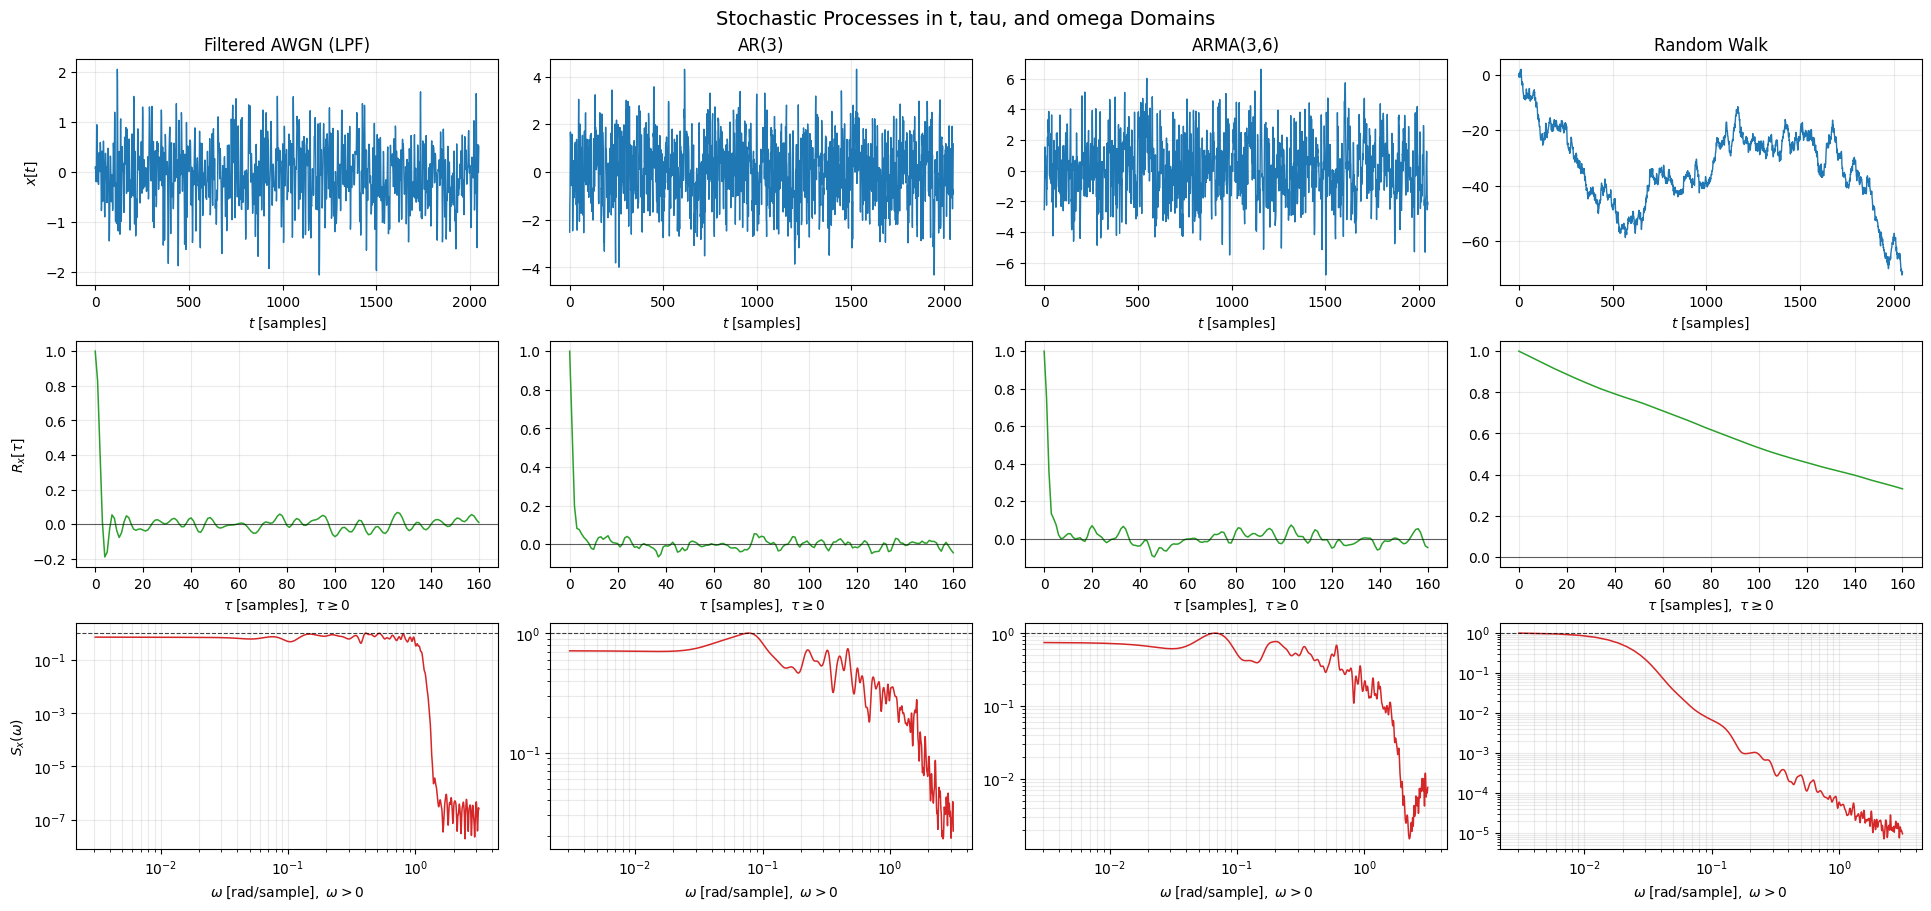

In [31]:
process_names = list(processes.keys())
num_processes = len(process_names)

fig, axes = plt.subplots(
    nrows=3,
    ncols=num_processes,
    figsize=(4.8 * num_processes, 9.0),
    constrained_layout=True,
)

# Keep a 2-D indexing shape even when there is only one process.
if num_processes == 1:
    axes = axes.reshape(3, 1)

for col, process_name in enumerate(process_names):
    process = processes[process_name]

    # Row 1: time-domain realization x[t].
    t_samples = np.arange(process.realization.size)
    ax_t = axes[0, col]
    ax_t.plot(t_samples, process.realization, color="tab:blue", linewidth=1.0)
    ax_t.set_title(process_name)
    ax_t.set_xlabel(r"$t\;[\mathrm{samples}]$")
    if col == 0:
        ax_t.set_ylabel(r"$x[t]$")
    ax_t.grid(alpha=0.25)

    # Row 2: lag-domain autocorrelation R_x[tau] (non-negative lags only).
    tau_samples, acf_values = process.acf
    nonnegative_lag_mask = tau_samples >= 0
    tau_nonnegative = tau_samples[nonnegative_lag_mask]
    acf_nonnegative = acf_values[nonnegative_lag_mask]

    ax_tau = axes[1, col]
    ax_tau.plot(tau_nonnegative, acf_nonnegative, color="tab:green", linewidth=1.1)
    ax_tau.axhline(0.0, color="black", linewidth=0.8, alpha=0.6)
    ax_tau.set_xlabel(r"$\tau\;[\mathrm{samples}],\ \tau \geq 0$")
    if col == 0:
        ax_tau.set_ylabel(r"$R_x[\tau]$")
    ax_tau.grid(alpha=0.25)

    # Row 3: PSD S_x[omega] on log-log axes, positive frequencies only.
    omega_rad, psd_values = process.psd
    positive_freq_mask = omega_rad > 0.0
    omega_pos = omega_rad[positive_freq_mask]
    psd_pos = np.maximum(psd_values[positive_freq_mask], np.finfo(float).eps)

    ax_omega = axes[2, col]
    ax_omega.loglog(omega_pos, psd_pos, color="tab:red", linewidth=1.1)
    # 0 dB corresponds to normalized power level 1.0.
    ax_omega.axhline(1.0, color="black", linestyle="--", linewidth=0.8, alpha=0.75)
    ax_omega.set_xlabel(r"$\omega\;[\mathrm{rad/sample}],\ \omega > 0$")
    if col == 0:
        ax_omega.set_ylabel(r"$S_x(\omega)$")
    ax_omega.grid(alpha=0.25, which="both")

fig.suptitle("Stochastic Processes in t, tau, and omega Domains", fontsize=14)


Given
$$
r_x(\lambda)=\sum_{k=-K}^{K} w_k\,e^{-\alpha_k\lambda^2},\qquad w_k\ge 0,
$$

Is $r_x(\lambda)$ a valid ACF?

For a wide-sense stationary (WSS) process, $r_x(\lambda)$ is a valid ACF **iff** it is positive semidefinite.
By **Bochner's theorem**, this is equivalent to saying its Fourier transform is a nonnegative spectral measure.

consider one term with $\alpha_k>0$:
$$
\mathcal{F}\{e^{-\alpha_k\lambda^2}\}(\omega)
=\sqrt{\frac{\pi}{\alpha_k}}\,e^{-\omega^2/(4\alpha_k)}\ge 0.
$$
Therefore, by linearity,
$$
S_x(\omega)=\mathcal{F}\{r_x(\lambda)\}
=\sum_{k=-K}^{K} w_k\sqrt{\frac{\pi}{\alpha_k}}\,e^{-\omega^2/(4\alpha_k)}\ge 0,
$$
so Wiener-Khinchin gives a valid ACF.

Special cases:
- If some $\alpha_k=0$, the term is constant $w_k$ and contributes $2\pi w_k\delta(\omega)$, still a nonnegative spectral measure.
- If any $\alpha_k<0$, that term grows like $e^{+|\alpha_k|\lambda^2}$, violating the covariance bound $|r_x(\lambda)|\le r_x(0)$, so it cannot be a valid WSS ACF.

**Conclusion:** the proposed form is a valid ACF when all $w_k\ge 0$ and all $\alpha_k\ge 0$ (typically $\alpha_k>0$ for a regular PSD density).



RMSE tolerance for model selection (tau > 0): 1e-08

Filtered AWGN (LPF)
  selection rule: best N within sweep
  N = 2
  RMSE(tau>0) = 0.037862
  RMSE(tau>=0) = 0.037745
  omega_n = [0.0109 0.9891]
  alpha_n = [0.2595 0.2595]

AR(3)
  selection rule: best N within sweep
  N = 15
  RMSE(tau>0) = 0.021973
  RMSE(tau>=0) = 0.021905
  omega_n = [0.0008 0.0005 0.0006 0.0006 0.0006 0.0005 0.0006 0.0005 0.0003 0.0005
 0.0004 0.0086 0.009  0.1659 0.8107]
  alpha_n = [0.003  0.0029 0.0004 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0003
 0.0004 0.0033 0.0053 0.0912 0.6606]

ARMA(3,6)
  selection rule: best N within sweep
  N = 20
  RMSE(tau>0) = 0.031554
  RMSE(tau>=0) = 0.031456
  omega_n = [0.0004 0.0003 0.0003 0.0003 0.0002 0.0003 0.0003 0.0003 0.0005 0.0004
 0.0003 0.0002 0.0002 0.0002 0.001  0.0047 0.0054 0.029  0.1293 0.8263]
  alpha_n = [0.0019 0.0012 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001
 0.0001 0.0001 0.0002 0.0002 0.0009 0.0021 0.0039 0.0278 0.0652 0.3367]

Random Wa

{'Filtered AWGN (LPF)': {'N': 2,
  'omega_n': array([0.01091575, 0.98908425]),
  'alpha_n': array([0.25953603, 0.25953603]),
  'mse_all': 0.0014246478919906936,
  'rmse_all': 0.03774450810370555,
  'mse_positive': 0.0014335519413156352,
  'rmse_positive': 0.037862275965869184,
  'selected_by_tolerance': False},
 'AR(3)': {'N': 15,
  'omega_n': array([7.96339428e-04, 5.37314828e-04, 6.14217283e-04, 5.67499162e-04,
         5.64013633e-04, 4.91712941e-04, 5.64906074e-04, 4.64540066e-04,
         3.25806669e-04, 4.90121295e-04, 3.89242118e-04, 8.62253273e-03,
         8.96377115e-03, 1.65875458e-01, 8.10732525e-01]),
  'alpha_n': array([3.03799352e-03, 2.92374939e-03, 4.36915508e-04, 1.45871382e-04,
         9.77677937e-05, 8.08944175e-05, 8.52423597e-05, 9.84643589e-05,
         1.36017218e-04, 3.06702982e-04, 3.55146755e-04, 3.29671995e-03,
         5.25956588e-03, 9.12136193e-02, 6.60597927e-01]),
  'mse_all': 0.00047981412069155886,
  'rmse_all': 0.021904659794015492,
  'mse_positive'

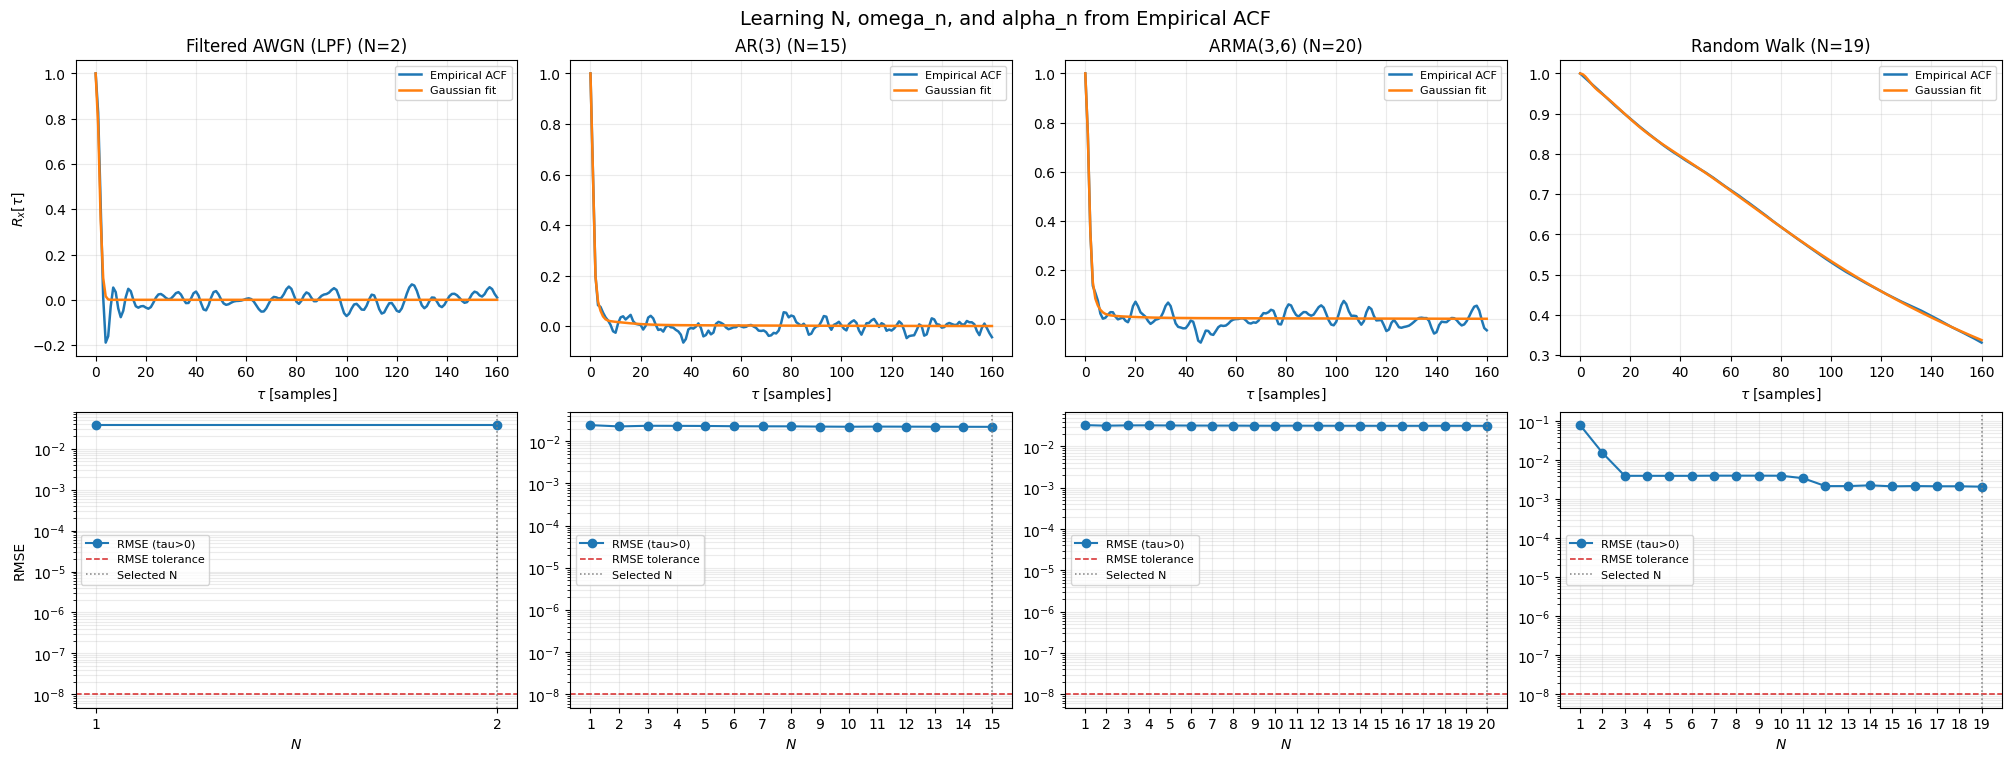

In [32]:
from dataclasses import dataclass


@dataclass(frozen=True)
class GaussianAcfLearningResult:
    """Stores learned Gaussian-mixture ACF parameters for one process."""

    N: int                                  # Selected model order
    omega_n: np.ndarray                     # Nonnegative weights that sum to one
    alpha_n: np.ndarray                     # Positive Gaussian decay rates [1/samples^2]
    mse_all: float                          # MSE on tau >= 0 (used for fit reporting)
    rmse_all: float                         # RMSE on tau >= 0
    mse_positive: float                     # MSE on tau > 0 (used for model selection)
    rmse_positive: float                    # RMSE on tau > 0 (used for model selection)
    tau_samples: np.ndarray                 # Nonnegative lags used for fitting [samples]
    target_acf: np.ndarray                  # Empirical ACF values at tau_samples
    fitted_acf: np.ndarray                  # Model ACF values at tau_samples
    mse_all_per_N: list[float]              # Sweep curve on tau >= 0
    mse_positive_per_N: list[float]         # Sweep curve on tau > 0
    selected_by_tolerance: bool             # True if first N below tolerance was found


def fit_acf_fixed_order(
    tau_samples: np.ndarray,                # Nonnegative lag indices [samples]
    target_acf: np.ndarray,                 # Empirical normalized ACF r_x[tau]
    N: int,                                 # Number of Gaussian components
    num_steps: int = 2500,                  # Gradient steps per restart
    learning_rate: float = 0.04,            # Adam learning rate
    num_restarts: int = 5,                  # Random restarts to reduce local minima risk
    base_seed: int = 1234,                  # Seed base for reproducible optimization
) -> tuple[np.ndarray, np.ndarray, float, float, np.ndarray]:
    """Fit omega_n and alpha_n for a fixed N by minimizing ACF MSE.

    Purpose:
        Solve
            r_hat(tau) = sum_n omega_n * exp(-alpha_n * tau^2)
        under the constraints omega_n >= 0, sum_n omega_n = 1, alpha_n > 0.

        The model is trained with tau >= 0, but model-selection metrics are
        tracked both on tau >= 0 and on tau > 0.

    Parameters:
        tau_samples: Nonnegative lag indices used for learning [samples].
        target_acf: Empirical normalized ACF values at the selected lags.
        N: Number of Gaussian basis functions in the model.
        num_steps: Optimization iterations for each restart.
        learning_rate: Step size for Adam.
        num_restarts: Number of initializations to try; best one is kept.
        base_seed: Deterministic seed base to keep reproducible runs.

    Returns:
        Tuple (omega_n, alpha_n, mse_all, mse_positive, fitted_acf) for the best
        restart according to mse_positive.

    Side effects:
        Uses PyTorch autograd/optimizer but does not mutate global state.

    Assumptions:
        tau_samples are nonnegative and target_acf has matching shape.
    """
    if N < 1:
        raise ValueError('N must be >= 1.')
    if tau_samples.ndim != 1 or target_acf.ndim != 1:
        raise ValueError('tau_samples and target_acf must be 1-D arrays.')
    if tau_samples.shape[0] != target_acf.shape[0]:
        raise ValueError('tau_samples and target_acf must have the same length.')
    if np.any(tau_samples < 0):
        raise ValueError('tau_samples must contain only nonnegative lags.')

    tau_float = tau_samples.astype(np.float64)
    target_float = target_acf.astype(np.float64)

    tau_tensor = torch.as_tensor(tau_float, dtype=torch.float64)
    target_tensor = torch.as_tensor(target_float, dtype=torch.float64)
    tau_squared = tau_tensor**2

    positive_mask_tensor = tau_tensor > 0
    if not bool(torch.any(positive_mask_tensor)):
        positive_mask_tensor = tau_tensor >= 0

    tau_max_samples = max(float(np.max(tau_float)), 1.0)
    alpha_min = 1.0e-7
    alpha_max = max(8.0 / (tau_max_samples**2), 1.0e-3)

    best_mse_positive = float('inf')
    best_omega_n = np.empty(0, dtype=np.float64)
    best_alpha_n = np.empty(0, dtype=np.float64)
    best_mse_all = float('inf')
    best_fitted = np.empty(0, dtype=np.float64)

    # Run multiple restarts and keep the best local optimum by positive-lag MSE.
    for restart_idx in range(num_restarts):
        generator = torch.Generator().manual_seed(base_seed + 997 * N + restart_idx)

        raw_logits = torch.nn.Parameter(
            0.15 * torch.randn(N, dtype=torch.float64, generator=generator)
        )

        # Initialize alpha_n on a log grid to cover both slow and fast decays.
        alpha_grid = torch.logspace(
            np.log10(alpha_min),
            np.log10(alpha_max),
            N,
            dtype=torch.float64,
        )
        alpha_perturbation = 1.0 + 0.2 * torch.randn(N, dtype=torch.float64, generator=generator)
        alpha_init = torch.clamp(alpha_grid * alpha_perturbation, min=alpha_min)
        raw_alpha = torch.nn.Parameter(torch.log(torch.expm1(alpha_init)))

        optimizer = torch.optim.Adam([raw_logits, raw_alpha], lr=learning_rate)

        for _ in range(num_steps):
            optimizer.zero_grad()

            omega_n = torch.softmax(raw_logits, dim=0)
            alpha_n = torch.nn.functional.softplus(raw_alpha) + 1.0e-9

            # Build Gaussian basis over tau and combine it with nonnegative weights.
            basis_matrix = torch.exp(-tau_squared[:, None] * alpha_n[None, :])
            fitted_tensor = basis_matrix @ omega_n

            # Train on tau >= 0 to keep the full ACF fit constrained and stable.
            mse_train_tensor = torch.mean((fitted_tensor - target_tensor) ** 2)

            mse_train_tensor.backward()
            optimizer.step()

        with torch.no_grad():
            omega_n = torch.softmax(raw_logits, dim=0)
            alpha_n = torch.nn.functional.softplus(raw_alpha) + 1.0e-9
            basis_matrix = torch.exp(-tau_squared[:, None] * alpha_n[None, :])
            fitted_tensor = basis_matrix @ omega_n

            residual_tensor = fitted_tensor - target_tensor
            mse_all_value = float(torch.mean(residual_tensor**2).item())
            mse_positive_value = float(torch.mean(residual_tensor[positive_mask_tensor] ** 2).item())

        if mse_positive_value < best_mse_positive:
            best_mse_positive = mse_positive_value
            best_mse_all = mse_all_value
            best_omega_n = omega_n.cpu().numpy()
            best_alpha_n = alpha_n.cpu().numpy()
            best_fitted = fitted_tensor.cpu().numpy()

    return best_omega_n, best_alpha_n, best_mse_all, best_mse_positive, best_fitted


def learn_gaussian_acf_parameters(
    process: StochasticProcess,             # Process realization + ACF/PSD bundle
    N_max: int = 10,                        # Maximum model order considered in sweep
    rmse_tolerance: float = 1e-8,           # Stop criterion on positive-lag RMSE
    num_steps: int = 2500,                  # Optimizer steps per fixed-order fit
    learning_rate: float = 0.04,            # Adam learning rate
    num_restarts: int = 5,                  # Random restarts per fixed N
    base_seed: int = 1234,                  # Reproducibility seed base
) -> GaussianAcfLearningResult:
    """Run K-sweep and learn N, omega_n, and alpha_n for one process.

    Purpose:
        Find the smallest N for which the Gaussian-mixture ACF model satisfies
        a positive-lag RMSE tolerance (tau > 0). If no N satisfies it, keep the
        globally best N among 1..N_max according to positive-lag MSE.

    Parameters:
        process: StochasticProcess instance containing empirical ACF.
        N_max: Maximum candidate order to evaluate.
        rmse_tolerance: Acceptance threshold for sqrt(MSE) on tau > 0.
        num_steps: Optimizer iterations used in each fixed-order fit.
        learning_rate: Adam learning rate for parameter updates.
        num_restarts: Number of random initializations per N.
        base_seed: Seed base for deterministic optimization.

    Returns:
        GaussianAcfLearningResult with selected N and learned parameter vectors.

    Side effects:
        None.

    Assumptions:
        ACF has finite values and includes lag tau=0.
    """
    if N_max < 1:
        raise ValueError('N_max must be >= 1.')
    if rmse_tolerance <= 0.0:
        raise ValueError('rmse_tolerance must be positive.')

    tau_samples_all, acf_all = process.acf
    nonnegative_mask = tau_samples_all >= 0
    tau_nonnegative = tau_samples_all[nonnegative_mask].astype(np.float64)
    acf_nonnegative = np.asarray(acf_all[nonnegative_mask], dtype=np.float64)

    if tau_nonnegative.size == 0:
        raise ValueError('ACF must contain at least one nonnegative lag sample.')

    mse_all_per_N: list[float] = []
    mse_positive_per_N: list[float] = []
    selected_result: GaussianAcfLearningResult | None = None
    best_result: GaussianAcfLearningResult | None = None

    # Sweep model order and stop at the first order satisfying the tolerance.
    for N in range(1, N_max + 1):
        omega_n, alpha_n, mse_all_value, mse_positive_value, fitted_acf = fit_acf_fixed_order(
            tau_samples=tau_nonnegative,
            target_acf=acf_nonnegative,
            N=N,
            num_steps=num_steps,
            learning_rate=learning_rate,
            num_restarts=num_restarts,
            base_seed=base_seed,
        )
        mse_all_per_N.append(mse_all_value)
        mse_positive_per_N.append(mse_positive_value)

        rmse_all_value = float(np.sqrt(mse_all_value))
        rmse_positive_value = float(np.sqrt(mse_positive_value))

        candidate = GaussianAcfLearningResult(
            N=N,
            omega_n=omega_n,
            alpha_n=alpha_n,
            mse_all=mse_all_value,
            rmse_all=rmse_all_value,
            mse_positive=mse_positive_value,
            rmse_positive=rmse_positive_value,
            tau_samples=tau_nonnegative,
            target_acf=acf_nonnegative,
            fitted_acf=fitted_acf,
            mse_all_per_N=mse_all_per_N.copy(),
            mse_positive_per_N=mse_positive_per_N.copy(),
            selected_by_tolerance=rmse_positive_value <= rmse_tolerance,
        )

        if best_result is None or mse_positive_value < best_result.mse_positive:
            best_result = candidate

        if selected_result is None and rmse_positive_value <= rmse_tolerance:
            selected_result = candidate

    if selected_result is not None:
        return selected_result
    assert best_result is not None  # N_max >= 1 guarantees at least one candidate.
    return best_result


# Hyperparameters for learning and model-order selection.
N_max = 25
rmse_tolerance = 1e-8
num_steps = 2500
learning_rate = 0.04
num_restarts = 5
base_seed = 2026

# Learn parameters independently for each stochastic process in the notebook.
learning_results: dict[str, GaussianAcfLearningResult] = {
    process_name: learn_gaussian_acf_parameters(
        process=process,
        N_max=N_max,
        rmse_tolerance=rmse_tolerance,
        num_steps=num_steps,
        learning_rate=learning_rate,
        num_restarts=num_restarts,
        base_seed=base_seed,
    )
    for process_name, process in processes.items()
}

# Create a compact, reusable dictionary with the learned parameters.
learned_parameters = {
    process_name: {
        'N': result.N,
        'omega_n': result.omega_n,
        'alpha_n': result.alpha_n,
        'mse_all': result.mse_all,
        'rmse_all': result.rmse_all,
        'mse_positive': result.mse_positive,
        'rmse_positive': result.rmse_positive,
        'selected_by_tolerance': result.selected_by_tolerance,
    }
    for process_name, result in learning_results.items()
}

print(f'RMSE tolerance for model selection (tau > 0): {rmse_tolerance}\n')
for process_name, result in learning_results.items():
    status_label = 'first N meeting tolerance' if result.selected_by_tolerance else 'best N within sweep'
    omega_str = np.array2string(result.omega_n, precision=4, suppress_small=True)
    alpha_str = np.array2string(result.alpha_n, precision=4, suppress_small=True)

    print(f'{process_name}')
    print(f'  selection rule: {status_label}')
    print(f'  N = {result.N}')
    print(f'  RMSE(tau>0) = {result.rmse_positive:.6f}')
    print(f'  RMSE(tau>=0) = {result.rmse_all:.6f}')
    print(f'  omega_n = {omega_str}')
    print(f'  alpha_n = {alpha_str}')
    print()


process_names = list(learning_results.keys())
num_processes = len(process_names)

fig, axes = plt.subplots(
    nrows=2,
    ncols=num_processes,
    figsize=(5.0 * num_processes, 7.5),
    constrained_layout=True,
)
if num_processes == 1:
    axes = axes.reshape(2, 1)

for col, process_name in enumerate(process_names):
    result = learning_results[process_name]

    # Top row: empirical ACF versus learned Gaussian-mixture fit.
    ax_fit = axes[0, col]
    ax_fit.plot(result.tau_samples, result.target_acf, label='Empirical ACF', linewidth=1.8)
    ax_fit.plot(result.tau_samples, result.fitted_acf, label='Gaussian fit', linewidth=1.8)
    ax_fit.set_title(f"{process_name} (N={result.N})")
    ax_fit.set_xlabel(r'$\tau\;[\mathrm{samples}]$')
    if col == 0:
        ax_fit.set_ylabel(r'$R_x[\tau]$')
    ax_fit.grid(alpha=0.25)
    ax_fit.legend(loc='best', fontsize=8)

    # Bottom row: K-sweep curve on tau>0 and selection threshold.
    ax_err = axes[1, col]
    N_values = np.arange(1, len(result.mse_positive_per_N) + 1)
    rmse_curve_positive = np.sqrt(np.maximum(result.mse_positive_per_N, np.finfo(float).eps))
    ax_err.semilogy(N_values, rmse_curve_positive, marker='o', linewidth=1.5, label='RMSE (tau>0)')
    ax_err.axhline(rmse_tolerance, color='tab:red', linestyle='--', linewidth=1.1, label='RMSE tolerance')
    ax_err.axvline(result.N, color='tab:gray', linestyle=':', linewidth=1.1, label='Selected N')
    ax_err.set_xlabel(r'$N$')
    if col == 0:
        ax_err.set_ylabel('RMSE')
    ax_err.set_xticks(N_values)
    ax_err.grid(alpha=0.25, which='both')
    ax_err.legend(loc='best', fontsize=8)

fig.suptitle('Learning N, omega_n, and alpha_n from Empirical ACF', fontsize=14)

learned_parameters
